# 03 — System A Internal Validation

## 1. Objective

This notebook evaluates the frozen clinical prediction pipeline within
Health System A before any examination of Health System B.

The study design is already frozen:

- **Landmark:** ICU hour 6
- **Prediction window:** ICU hours 6–18
- **Development cohort:** Health System A
- **Eligible patients:** 18,699
- **Incident sepsis events:** 371
- **Frozen engineered predictors:** 84
- **External validation cohort:** Health System B

The goals of this notebook are to:

1. estimate internal predictive performance using out-of-fold predictions;
2. tune model-specific hyperparameters without leakage;
3. compare discrimination, probabilistic accuracy, and calibration;
4. generate a frozen modeling pipeline for subsequent external validation.

Health System B remains completely untouched.

## 2. Specified Internal Validation Design

Internal validation uses nested stratified cross-validation.

### Outer validation

A 5-fold stratified outer cross-validation is used to generate one
out-of-fold prediction for every System A patient.

Each outer validation fold remains completely untouched during model
training and hyperparameter selection.

### Inner model tuning

Within each outer training set, model-specific hyperparameters are tuned
using 3-fold stratified cross-validation.

Hyperparameter selection is based on probabilistic prediction quality
rather than classification accuracy.

### Specified model classes

Three model classes will be evaluated:

1. **Ridge logistic regression**
2. **Elastic-net logistic regression**
3. **LightGBM**

All three model classes will subsequently undergo external validation in
Health System B. No model class is discarded solely because another model
performs better internally.

### Primary evaluation quantities

Internal out-of-fold predictions will be evaluated using:

- Brier score;
- log loss;
- AUROC;
- AUPRC;
- calibration-in-the-large;
- joint calibration intercept;
- calibration slope;
- calibration curves.

Calibration-in-the-large is the intercept estimated with calibration
slope fixed at 1. The joint calibration intercept and slope are estimated
from the logistic calibration model
$\operatorname{logit}(Y)=\alpha+\beta\operatorname{logit}(p)$.

No fixed classification threshold is used for primary model comparison.

### Class imbalance

No SMOTE, random oversampling, undersampling, or class weighting is used
in the primary analysis.

The observed event prevalence is preserved because calibrated probability
estimation is a central study objective.


## 3. Load the Frozen System A Matrix

Load the cleaned and frozen patient-level feature matrix created in the
feature availability and missingness audit.

No feature definition is changed in this notebook.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold


ROOT = Path.cwd()

if not (ROOT / "data").exists():
    ROOT = ROOT.parent

SYSTEM_A_FEATURE_PATH = (
    ROOT
    / "data"
    / "processed"
    / "system_a_features.csv"
)

system_a = pd.read_csv(
    SYSTEM_A_FEATURE_PATH
)

print(
    f"Loaded System A matrix: "
    f"{system_a.shape[0]:,} patients × "
    f"{system_a.shape[1]:,} total columns"
)

system_a.head()

Loaded System A matrix: 18,699 patients × 86 total columns


,patient_id,outcome,Age,Gender,HospAdmTime,ICU_unit_Unit1,ICU_unit_Unit2,HR__last,HR__mean,HR__min,...,Phosphate__last,Phosphate__available,SaO2__last,SaO2__available,Lactate__last,Lactate__available,AST__last,AST__available,Alkalinephos__last,Alkalinephos__available
0,p000001,0,83.14,0,-0.03,0,0,110.0,97.8,89.0,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
1,p000002,0,75.91,0,-98.60,0,1,94.0,68.2,56.0,...,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
2,p000003,0,45.82,0,-1195.71,1,0,84.0,88.6,84.0,...,2.4,1,NaN,0,NaN,0,NaN,0,NaN,0
3,p000004,0,65.71,0,-8.77,0,1,107.0,107.8,103.5,...,NaN,0,98.0,1,NaN,0,NaN,0,NaN,0
4,p000005,0,28.09,1,-0.05,1,0,71.0,76.4,71.0,...,2.8,1,NaN,0,NaN,0,16.0,1,65.0,1


In [2]:
ID_COLUMN = "patient_id"
OUTCOME_COLUMN = "outcome"

feature_columns = [
    col
    for col in system_a.columns
    if col not in [
        ID_COLUMN,
        OUTCOME_COLUMN,
    ]
]

matrix_check = pd.Series(
    {
        "patients": len(system_a),
        "model_features": len(feature_columns),
        "positive_events": int(
            system_a[OUTCOME_COLUMN].sum()
        ),
        "event_rate": (
            system_a[OUTCOME_COLUMN].mean()
        ),
        "duplicate_patient_ids": int(
            system_a[ID_COLUMN]
            .duplicated()
            .sum()
        ),
        "missing_outcomes": int(
            system_a[OUTCOME_COLUMN]
            .isna()
            .sum()
        ),
    },
    name="Frozen System A matrix",
)

matrix_check.to_frame()

,Frozen System A matrix
patients,18699.000000
model_features,84.000000
positive_events,371.000000
event_rate,0.019841
duplicate_patient_ids,0.000000
missing_outcomes,0.000000


## 4. Feature Roles and Preprocessing Boundaries

The frozen matrix contains continuous clinical-value features together
with binary context and availability indicators.

For linear models:

- continuous variables will be median-imputed using the outer-training
  data only;
- continuous variables will then be standardized using outer-training
  data only;
- binary indicators will be passed through without scaling.

All preprocessing operations will occur inside the cross-validation
pipeline to prevent information leakage.

For LightGBM, missing clinical values will remain as `NaN` and will be
handled natively by the model. No scaling is required.

In [3]:
binary_feature_columns = (
    [
        "Gender",
        "ICU_unit_Unit1",
        "ICU_unit_Unit2",
    ]
    + [
        col
        for col in feature_columns
        if col.endswith("__available")
    ]
)

continuous_feature_columns = [
    col
    for col in feature_columns
    if col not in binary_feature_columns
]

assert (
    len(binary_feature_columns)
    + len(continuous_feature_columns)
    == len(feature_columns)
)

binary_integrity_records = []

for col in binary_feature_columns:
    observed_values = set(
        system_a[col]
        .dropna()
        .unique()
    )

    binary_integrity_records.append(
        {
            "feature": col,
            "observed_values": sorted(
                observed_values
            ),
            "valid_binary": (
                observed_values
                <= {0, 1}
            ),
            "missing_values": int(
                system_a[col]
                .isna()
                .sum()
            ),
        }
    )

binary_feature_audit = pd.DataFrame(
    binary_integrity_records
)

print(
    f"Continuous features: "
    f"{len(continuous_feature_columns)}"
)

print(
    f"Binary features: "
    f"{len(binary_feature_columns)}"
)

binary_feature_audit

Continuous features: 52
Binary features: 32


,feature,observed_values,valid_binary,missing_values
0,Gender,"[0, 1]",True,0
1,ICU_unit_Unit1,"[0, 1]",True,0
2,ICU_unit_Unit2,"[0, 1]",True,0
3,HR__available,"[0, 1]",True,0
4,MAP__available,"[0, 1]",True,0
5,O2Sat__available,"[0, 1]",True,0
6,Resp__available,"[0, 1]",True,0
7,SBP__available,"[0, 1]",True,0
8,Temp__available,"[0, 1]",True,0
9,DBP__available,"[0, 1]",True,0


## 5. Frozen Nested Cross-Validation Structure

A deterministic random seed is used to make the internal validation
structure exactly reproducible.

The same outer folds will be used for every model class so that model
performance is compared on identical patients.

Stratification preserves approximately the same sepsis event prevalence
within each fold.

In [4]:
RANDOM_STATE = 20260919

N_OUTER_FOLDS = 5
N_INNER_FOLDS = 3

X = system_a[
    feature_columns
].copy()

y = system_a[
    OUTCOME_COLUMN
].astype(int).copy()

outer_cv = StratifiedKFold(
    n_splits=N_OUTER_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

outer_fold = np.zeros(
    len(system_a),
    dtype=int,
)

for fold_id, (_, validation_idx) in enumerate(
    outer_cv.split(X, y),
    start=1,
):
    outer_fold[validation_idx] = fold_id

assert (outer_fold > 0).all()

fold_assignments = pd.DataFrame(
    {
        "patient_id": system_a[
            ID_COLUMN
        ],
        "outcome": y,
        "outer_fold": outer_fold,
    }
)

fold_summary = (
    fold_assignments
    .groupby("outer_fold")
    .agg(
        patients=("patient_id", "size"),
        positive_events=("outcome", "sum"),
        event_rate=("outcome", "mean"),
    )
)

fold_summary

,patients,positive_events,event_rate
outer_fold,,,
1,3740,74,0.019786
2,3740,74,0.019786
3,3740,74,0.019786
4,3740,75,0.020053
5,3739,74,0.019791


In [5]:
outer_training_summary = []

for fold_id in range(
    1,
    N_OUTER_FOLDS + 1,
):
    validation_mask = (
        outer_fold == fold_id
    )

    training_y = y.loc[
        ~validation_mask
    ]

    validation_y = y.loc[
        validation_mask
    ]

    outer_training_summary.append(
        {
            "outer_fold": fold_id,

            "training_patients": len(
                training_y
            ),

            "training_events": int(
                training_y.sum()
            ),

            "validation_patients": len(
                validation_y
            ),

            "validation_events": int(
                validation_y.sum()
            ),
        }
    )

outer_training_summary = pd.DataFrame(
    outer_training_summary
)

outer_training_summary

,outer_fold,training_patients,training_events,validation_patients,validation_events
0,1,14959,297,3740,74
1,2,14959,297,3740,74
2,3,14959,297,3740,74
3,4,14959,296,3740,75
4,5,14960,297,3739,74


## 6. Ridge Logistic Regression

Ridge logistic regression provides a regularized linear benchmark for
probabilistic sepsis prediction.

For each outer fold:

1. preprocessing is fitted using the outer-training data only;
2. the regularization parameter is selected using 3-fold stratified
   inner cross-validation;
3. the tuned pipeline is refitted on the complete outer-training set;
4. probabilities are generated for the untouched outer-validation fold.

Continuous predictors are median-imputed and standardized inside the
cross-validation pipeline. Binary predictors are passed through
unchanged.

The inverse regularization strength \(C\) is tuned using **log loss**,
a proper probabilistic scoring rule. No class weighting or resampling is
used.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


continuous_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "continuous",
            continuous_preprocessor,
            continuous_feature_columns,
        ),
        (
            "binary",
            "passthrough",
            binary_feature_columns,
        ),
    ],
    remainder="drop",
)

ridge_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "model",
            LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                max_iter=5000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

ridge_param_grid = {
    "model__C": [
        0.001,
        0.003,
        0.01,
        0.03,
        0.1,
        0.3,
        1.0,
        3.0,
        10.0,
    ]
}

ridge_param_grid

{'model__C': [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]}

### Nested Cross-Validation

The same frozen outer-fold assignments are used for Ridge logistic
regression and all later model classes.

Hyperparameter tuning occurs independently within each outer-training
set. The outer-validation fold is never used to select \(C\).

In [7]:
ridge_oof_probability = np.full(
    len(system_a),
    np.nan,
)

ridge_fold_records = []

for fold_id in range(
    1,
    N_OUTER_FOLDS + 1,
):
    print(
        f"Running outer fold "
        f"{fold_id}/{N_OUTER_FOLDS}..."
    )

    validation_mask = (
        outer_fold == fold_id
    )

    training_idx = np.where(
        ~validation_mask
    )[0]

    validation_idx = np.where(
        validation_mask
    )[0]

    X_train = X.iloc[
        training_idx
    ]

    y_train = y.iloc[
        training_idx
    ]

    X_valid = X.iloc[
        validation_idx
    ]

    y_valid = y.iloc[
        validation_idx
    ]

    inner_cv = StratifiedKFold(
        n_splits=N_INNER_FOLDS,
        shuffle=True,
        random_state=(
            RANDOM_STATE + fold_id
        ),
    )

    ridge_search = GridSearchCV(
        estimator=ridge_pipeline,
        param_grid=ridge_param_grid,
        scoring="neg_log_loss",
        cv=inner_cv,
        refit=True,
        n_jobs=-1,
        return_train_score=False,
    )

    ridge_search.fit(
        X_train,
        y_train,
    )

    validation_probability = (
        ridge_search.predict_proba(
            X_valid
        )[:, 1]
    )

    ridge_oof_probability[
        validation_idx
    ] = validation_probability

    ridge_fold_records.append(
        {
            "outer_fold": fold_id,
            "training_patients": len(
                training_idx
            ),
            "training_events": int(
                y_train.sum()
            ),
            "validation_patients": len(
                validation_idx
            ),
            "validation_events": int(
                y_valid.sum()
            ),
            "best_C": (
                ridge_search.best_params_[
                    "model__C"
                ]
            ),
            "best_inner_log_loss": (
                -ridge_search.best_score_
            ),
        }
    )

assert not np.isnan(
    ridge_oof_probability
).any()

assert np.all(
    (ridge_oof_probability >= 0)
    & (ridge_oof_probability <= 1)
)

ridge_tuning_summary = pd.DataFrame(
    ridge_fold_records
)

ridge_tuning_summary

Running outer fold 1/5...
Running outer fold 2/5...
Running outer fold 3/5...
Running outer fold 4/5...
Running outer fold 5/5...


,outer_fold,training_patients,training_events,validation_patients,validation_events,best_C,best_inner_log_loss
0,1,14959,297,3740,74,0.10,0.093732
1,2,14959,297,3740,74,0.03,0.093342
2,3,14959,297,3740,74,0.10,0.093064
3,4,14959,296,3740,75,0.03,0.092876
4,5,14960,297,3739,74,0.03,0.094592


In [8]:
ridge_oof_summary = pd.Series(
    {
        "patients_with_predictions": int(
            np.isfinite(
                ridge_oof_probability
            ).sum()
        ),
        "minimum_probability": float(
            ridge_oof_probability.min()
        ),
        "median_probability": float(
            np.median(
                ridge_oof_probability
            )
        ),
        "mean_probability": float(
            ridge_oof_probability.mean()
        ),
        "maximum_probability": float(
            ridge_oof_probability.max()
        ),
        "observed_event_rate": float(
            y.mean()
        ),
    },
    name="Ridge OOF predictions",
)

ridge_oof_summary.to_frame()

,Ridge OOF predictions
patients_with_predictions,18699.000000
minimum_probability,0.000365
median_probability,0.014910
mean_probability,0.019879
maximum_probability,0.642742
observed_event_rate,0.019841


### Ridge Out-of-Fold Performance

Performance is evaluated exclusively from the pooled out-of-fold
predictions.

Because every probability was generated for a patient who was excluded
from the corresponding outer-training set, these estimates represent
internal validation rather than apparent training performance.

Evaluation includes:

- Brier score;
- log loss;
- AUROC;
- AUPRC;
- calibration-in-the-large;
- joint calibration intercept;
- calibration slope.

Calibration-in-the-large fixes the coefficient of the prediction
log-odds at 1 and estimates only an intercept correction.

The joint calibration intercept and slope are estimated simultaneously
from the logistic calibration model.

Ideal calibration corresponds to:

- calibration-in-the-large = 0;
- joint calibration intercept = 0;
- calibration slope = 1.


In [9]:
from scipy.optimize import brentq, root
from scipy.special import expit

from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
)


CALIBRATION_EPSILON = 1e-6


def safe_logit(
    predicted_probability,
):
    probability = np.clip(
        np.asarray(
            predicted_probability,
            dtype=float,
        ),
        CALIBRATION_EPSILON,
        1 - CALIBRATION_EPSILON,
    )

    return np.log(
        probability
        / (1 - probability)
    )


def estimate_calibration_in_the_large(
    y_true,
    predicted_probability,
):
    y_true = np.asarray(
        y_true,
        dtype=float,
    )

    predicted_logit = safe_logit(
        predicted_probability
    )

    def score(alpha):
        calibrated_probability = expit(
            alpha + predicted_logit
        )

        return float(
            calibrated_probability.sum()
            - y_true.sum()
        )

    return float(
        brentq(
            score,
            -50,
            50,
            xtol=1e-12,
            rtol=1e-12,
        )
    )


def estimate_calibration_parameters(
    y_true,
    predicted_probability,
):
    y_true = np.asarray(
        y_true,
        dtype=float,
    )

    predicted_logit = safe_logit(
        predicted_probability
    )

    calibration_in_the_large = (
        estimate_calibration_in_the_large(
            y_true,
            predicted_probability,
        )
    )

    def score(parameters):
        intercept = parameters[0]
        slope = parameters[1]

        calibrated_probability = expit(
            intercept
            + slope * predicted_logit
        )

        residual = (
            calibrated_probability
            - y_true
        )

        return np.array(
            [
                residual.sum(),
                np.sum(
                    residual
                    * predicted_logit
                ),
            ]
        )

    def jacobian(parameters):
        intercept = parameters[0]
        slope = parameters[1]

        calibrated_probability = expit(
            intercept
            + slope * predicted_logit
        )

        weight = (
            calibrated_probability
            * (1 - calibrated_probability)
        )

        weighted_logit = (
            weight
            * predicted_logit
        )

        return np.array(
            [
                [
                    weight.sum(),
                    weighted_logit.sum(),
                ],
                [
                    weighted_logit.sum(),
                    np.sum(
                        weighted_logit
                        * predicted_logit
                    ),
                ],
            ]
        )

    result = root(
        score,
        x0=np.array(
            [
                calibration_in_the_large,
                1.0,
            ]
        ),
        jac=jacobian,
        method="hybr",
    )

    score_norm = float(
        np.linalg.norm(
            score(
                result.x
            )
        )
    )

    if (
        not np.all(
            np.isfinite(
                result.x
            )
        )
        or score_norm > 1e-6
    ):
        raise RuntimeError(
            "Joint calibration-model estimation failed: "
            f"{result.message}; score norm={score_norm:.3e}"
        )

    return {
        "calibration_intercept":
            float(
                result.x[0]
            ),
        "calibration_slope":
            float(
                result.x[1]
            ),
    }


ridge_brier = brier_score_loss(
    y,
    ridge_oof_probability,
)

ridge_log_loss = log_loss(
    y,
    ridge_oof_probability,
    labels=[0, 1],
)

ridge_auroc = roc_auc_score(
    y,
    ridge_oof_probability,
)

ridge_auprc = average_precision_score(
    y,
    ridge_oof_probability,
)

ridge_calibration_in_the_large = (
    estimate_calibration_in_the_large(
        y,
        ridge_oof_probability,
    )
)

ridge_calibration = (
    estimate_calibration_parameters(
        y,
        ridge_oof_probability,
    )
)

ridge_calibration_intercept = float(
    ridge_calibration[
        "calibration_intercept"
    ]
)

ridge_calibration_slope = float(
    ridge_calibration[
        "calibration_slope"
    ]
)

ridge_metrics = pd.Series(
    {
        "Brier_score": ridge_brier,
        "log_loss": ridge_log_loss,
        "AUROC": ridge_auroc,
        "AUPRC": ridge_auprc,
        "calibration_in_the_large": (
            ridge_calibration_in_the_large
        ),
        "calibration_intercept": (
            ridge_calibration_intercept
        ),
        "calibration_slope": (
            ridge_calibration_slope
        ),
        "event_rate": float(
            y.mean()
        ),
    },
    name="Ridge logistic regression",
)

ridge_metrics.to_frame()


,Ridge logistic regression
Brier_score,0.019361
log_loss,0.093716
AUROC,0.684547
AUPRC,0.042632
calibration_in_the_large,-0.002008
calibration_intercept,-0.670100
calibration_slope,0.818027
event_rate,0.019841


### Outer-Fold Performance

Performance is also summarized separately within each outer validation
fold.

These fold-specific values are descriptive diagnostics for stability
across the specified validation partitions. The primary internal
performance estimates are calculated from the pooled out-of-fold
predictions.

In [10]:
ridge_fold_performance_records = []

for fold_id in range(
    1,
    N_OUTER_FOLDS + 1,
):
    fold_mask = (
        outer_fold == fold_id
    )

    fold_y = y.loc[
        fold_mask
    ]

    fold_probability = (
        ridge_oof_probability[
            fold_mask
        ]
    )

    ridge_fold_performance_records.append(
        {
            "outer_fold": fold_id,
            "patients": int(
                fold_mask.sum()
            ),
            "events": int(
                fold_y.sum()
            ),
            "event_rate": float(
                fold_y.mean()
            ),
            "Brier_score": (
                brier_score_loss(
                    fold_y,
                    fold_probability,
                )
            ),
            "log_loss": (
                log_loss(
                    fold_y,
                    fold_probability,
                )
            ),
            "AUROC": (
                roc_auc_score(
                    fold_y,
                    fold_probability,
                )
            ),
            "AUPRC": (
                average_precision_score(
                    fold_y,
                    fold_probability,
                )
            ),
        }
    )

ridge_fold_performance = pd.DataFrame(
    ridge_fold_performance_records
)

ridge_fold_performance

,outer_fold,patients,events,event_rate,Brier_score,log_loss,AUROC,AUPRC
0,1,3740,74,0.019786,0.019421,0.093473,0.703296,0.037522
1,2,3740,74,0.019786,0.019353,0.092734,0.696886,0.051623
2,3,3740,74,0.019786,0.019067,0.092489,0.692267,0.068759
3,4,3740,75,0.020053,0.019637,0.096472,0.643409,0.034975
4,5,3739,74,0.019791,0.019327,0.093411,0.685421,0.044096


In [11]:
constant_prevalence_oof_probability = np.full(
    len(y),
    np.nan,
)

for fold_id in range(
    1,
    N_OUTER_FOLDS + 1,
):
    validation_mask = (
        outer_fold == fold_id
    )

    training_prevalence = float(
        y.loc[
            ~validation_mask
        ].mean()
    )

    constant_prevalence_oof_probability[
        validation_mask
    ] = training_prevalence

assert np.isfinite(
    constant_prevalence_oof_probability
).all()


ridge_reference_summary = pd.Series(
    {
        "AUPRC_no_skill_reference": float(
            y.mean()
        ),
        "Brier_outer_training_prevalence_model": (
            brier_score_loss(
                y,
                constant_prevalence_oof_probability,
            )
        ),
        "Ridge_mean_predicted_risk": float(
            ridge_oof_probability.mean()
        ),
        "observed_event_rate": float(
            y.mean()
        ),
    },
    name="Reference quantities",
)

ridge_reference_summary.to_frame()

,Reference quantities
AUPRC_no_skill_reference,0.019841
Brier_outer_training_prevalence_model,0.019447
Ridge_mean_predicted_risk,0.019879
observed_event_rate,0.019841


### Bootstrap Confidence Intervals

Uncertainty in pooled out-of-fold performance is quantified using
patient-level nonparametric bootstrap resampling.

Each bootstrap sample resamples patients with replacement from the
complete set of out-of-fold predictions.

These intervals quantify sampling variability in the pooled validated
predictions. They do not repeat the full nested cross-validation
procedure and therefore should not be interpreted as uncertainty from
model redevelopment itself.

Two thousand bootstrap replicates are used with a fixed random seed.

In [12]:
N_BOOTSTRAP = 2000
BOOTSTRAP_RANDOM_STATE = 20260919

bootstrap_rng = np.random.default_rng(
    BOOTSTRAP_RANDOM_STATE
)

y_array = y.to_numpy()
p_array = ridge_oof_probability.copy()

bootstrap_records = []

for bootstrap_id in range(N_BOOTSTRAP):
    sample_idx = bootstrap_rng.integers(
        0,
        len(y_array),
        size=len(y_array),
    )

    y_boot = y_array[sample_idx]
    p_boot = p_array[sample_idx]

    if np.unique(y_boot).size < 2:
        continue

    calibration_in_the_large_boot = (
        estimate_calibration_in_the_large(
            y_boot,
            p_boot,
        )
    )

    calibration_boot = (
        estimate_calibration_parameters(
            y_boot,
            p_boot,
        )
    )

    bootstrap_records.append(
        {
            "Brier_score": brier_score_loss(
                y_boot,
                p_boot,
            ),
            "log_loss": log_loss(
                y_boot,
                p_boot,
                labels=[0, 1],
            ),
            "AUROC": roc_auc_score(
                y_boot,
                p_boot,
            ),
            "AUPRC": average_precision_score(
                y_boot,
                p_boot,
            ),
            "calibration_in_the_large": (
                calibration_in_the_large_boot
            ),
            "calibration_intercept": (
                calibration_boot[
                    "calibration_intercept"
                ]
            ),
            "calibration_slope": (
                calibration_boot[
                    "calibration_slope"
                ]
            ),
        }
    )

ridge_bootstrap = pd.DataFrame(
    bootstrap_records
)

print(
    f"Completed bootstrap replicates: "
    f"{len(ridge_bootstrap):,}"
)

ridge_bootstrap.head()


Completed bootstrap replicates: 2,000


,Brier_score,log_loss,AUROC,AUPRC,calibration_in_the_large,calibration_intercept,calibration_slope
0,0.019225,0.093927,0.670422,0.040510,-0.009276,-0.998113,0.732546
1,0.018924,0.091687,0.693519,0.044177,-0.028807,-0.552105,0.856897
2,0.018302,0.088799,0.702292,0.042798,-0.064669,-0.513407,0.877060
3,0.019142,0.092095,0.703075,0.044279,-0.012133,-0.444531,0.881652
4,0.018467,0.089512,0.700207,0.044293,-0.069473,-0.701319,0.826444


In [13]:
ridge_point_estimates = {
    "Brier_score": ridge_brier,
    "log_loss": ridge_log_loss,
    "AUROC": ridge_auroc,
    "AUPRC": ridge_auprc,
    "calibration_in_the_large":
        ridge_calibration_in_the_large,
    "calibration_intercept":
        ridge_calibration_intercept,
    "calibration_slope":
        ridge_calibration_slope,
}

ridge_ci_records = []

for metric, estimate in ridge_point_estimates.items():
    lower = ridge_bootstrap[
        metric
    ].quantile(0.025)

    upper = ridge_bootstrap[
        metric
    ].quantile(0.975)

    ridge_ci_records.append(
        {
            "metric": metric,
            "estimate": estimate,
            "lower_95_ci": lower,
            "upper_95_ci": upper,
        }
    )

ridge_confidence_intervals = pd.DataFrame(
    ridge_ci_records
)

ridge_confidence_intervals


,metric,estimate,lower_95_ci,upper_95_ci
0,Brier_score,0.019361,0.017455,0.021215
1,log_loss,0.093716,0.086023,0.101183
2,AUROC,0.684547,0.657733,0.709465
3,AUPRC,0.042632,0.035842,0.053673
4,calibration_in_the_large,-0.002008,-0.114936,0.094959
5,calibration_intercept,-0.670100,-1.156192,-0.229765
6,calibration_slope,0.818027,0.695247,0.938367


### Calibration Curve

Calibration is examined graphically using deciles of predicted risk
from the pooled out-of-fold predictions.

Patients are grouped into ten approximately equal-sized groups according
to predicted probability. Within each group, the mean predicted risk is
compared with the observed event proportion.

The plot is descriptive and complements calibration-in-the-large, the
joint calibration intercept, and the calibration slope reported above.

In [14]:
ridge_calibration_data = pd.DataFrame(
    {
        "outcome": y.to_numpy(),
        "predicted_probability":
            ridge_oof_probability,
    }
)

ridge_calibration_data[
    "risk_decile"
] = pd.qcut(
    ridge_calibration_data[
        "predicted_probability"
    ],
    q=10,
    labels=False,
    duplicates="drop",
)

ridge_calibration_table = (
    ridge_calibration_data
    .groupby(
        "risk_decile",
        observed=True,
    )
    .agg(
        patients=(
            "outcome",
            "size",
        ),
        events=(
            "outcome",
            "sum",
        ),
        mean_predicted_risk=(
            "predicted_probability",
            "mean",
        ),
        observed_event_rate=(
            "outcome",
            "mean",
        ),
        minimum_predicted_risk=(
            "predicted_probability",
            "min",
        ),
        maximum_predicted_risk=(
            "predicted_probability",
            "max",
        ),
    )
    .reset_index()
)

ridge_calibration_table[
    "risk_decile"
] = (
    ridge_calibration_table[
        "risk_decile"
    ]
    + 1
)

ridge_calibration_table

,risk_decile,patients,events,mean_predicted_risk,observed_event_rate,minimum_predicted_risk,maximum_predicted_risk
0,1,1870,8,0.004966,0.004278,0.000365,0.006419
1,2,1870,17,0.007414,0.009091,0.006420,0.008388
2,3,1870,15,0.009364,0.008021,0.008389,0.010321
3,4,1870,24,0.011375,0.012834,0.010322,0.012487
4,5,1870,27,0.013696,0.014439,0.012487,0.014910
5,6,1869,34,0.016219,0.018192,0.014911,0.017670
6,7,1870,42,0.019356,0.022460,0.017671,0.021198
7,8,1870,44,0.023730,0.023529,0.021199,0.026749
8,9,1870,68,0.031376,0.036364,0.026756,0.037698
9,10,1870,92,0.061291,0.049198,0.037706,0.642742


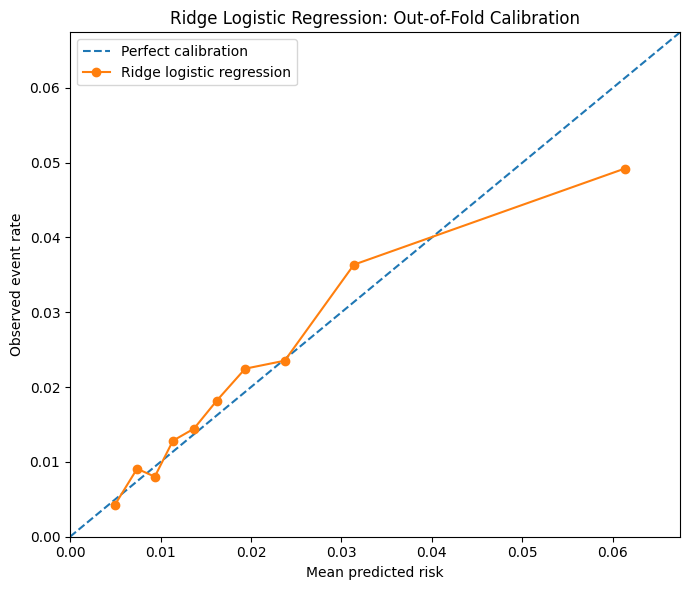

In [15]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(
    figsize=(7, 6)
)

maximum_risk = max(
    ridge_calibration_table[
        "mean_predicted_risk"
    ].max(),
    ridge_calibration_table[
        "observed_event_rate"
    ].max(),
)

plot_limit = maximum_risk * 1.10

ax.plot(
    [0, plot_limit],
    [0, plot_limit],
    linestyle="--",
    label="Perfect calibration",
)

ax.plot(
    ridge_calibration_table[
        "mean_predicted_risk"
    ],
    ridge_calibration_table[
        "observed_event_rate"
    ],
    marker="o",
    label="Ridge logistic regression",
)

ax.set_xlim(
    0,
    plot_limit,
)

ax.set_ylim(
    0,
    plot_limit,
)

ax.set_xlabel(
    "Mean predicted risk"
)

ax.set_ylabel(
    "Observed event rate"
)

ax.set_title(
    "Ridge Logistic Regression: "
    "Out-of-Fold Calibration"
)

ax.legend()

plt.tight_layout()
plt.show()

### Ridge Internal-Validation Summary

Ridge logistic regression showed modest discrimination in System A
internal validation.

The pooled out-of-fold AUROC was 0.685 (95% CI 0.658–0.709) and the
pooled out-of-fold AUPRC was 0.043 (95% CI 0.036–0.054), exceeding the
no-skill prevalence baseline of approximately 0.020.

Calibration-in-the-large was close to ideal (approximately 0), indicating
little overall bias in the average predicted risk. However, the
calibration slope was below 1 (0.818, 95% CI 0.695–0.938), indicating
over-dispersed predictions.

The decile-based calibration table was consistent with this pattern:
predicted risk tended to be somewhat too low in parts of the lower-risk
range and somewhat too high in the highest-risk group.

Ridge logistic regression is therefore retained as a regularized linear
baseline for subsequent comparison with Elastic-Net logistic regression
and LightGBM.

## 7. Elastic-Net Logistic Regression

Elastic-net logistic regression extends the regularized linear baseline
by combining L1 and L2 penalties.

The L1 component can shrink some coefficients exactly to zero, while the
L2 component stabilizes estimation when predictors are correlated.

The same frozen nested cross-validation structure used for Ridge logistic
regression is retained:

- 5 outer folds for internal validation;
- 3 inner folds for hyperparameter tuning;
- identical outer-fold assignments across model classes;
- log loss as the inner tuning criterion;
- no class weighting or resampling.

Two hyperparameters are tuned:

- \(C\): inverse overall regularization strength;
- `l1_ratio`: relative contribution of the L1 penalty.

All preprocessing remains inside the cross-validation pipeline.

In [16]:
elastic_net_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "model",
            LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                max_iter=10000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

elastic_net_param_grid = {
    "model__C": [
        0.003,
        0.01,
        0.03,
        0.1,
        0.3,
        1.0,
    ],
    "model__l1_ratio": [
        0.1,
        0.5,
        0.9,
    ],
}

elastic_net_param_grid

{'model__C': [0.003, 0.01, 0.03, 0.1, 0.3, 1.0],
 'model__l1_ratio': [0.1, 0.5, 0.9]}

### Nested Cross-Validation

Elastic-net hyperparameters are selected independently within each
outer-training set.

The corresponding outer-validation fold remains untouched until the
best combination of \(C\) and `l1_ratio` has been selected.

In [17]:
elastic_net_oof_probability = np.full(
    len(system_a),
    np.nan,
)

elastic_net_fold_records = []

for fold_id in range(
    1,
    N_OUTER_FOLDS + 1,
):
    print(
        f"Running outer fold "
        f"{fold_id}/{N_OUTER_FOLDS}..."
    )

    validation_mask = (
        outer_fold == fold_id
    )

    training_idx = np.where(
        ~validation_mask
    )[0]

    validation_idx = np.where(
        validation_mask
    )[0]

    X_train = X.iloc[
        training_idx
    ]

    y_train = y.iloc[
        training_idx
    ]

    X_valid = X.iloc[
        validation_idx
    ]

    y_valid = y.iloc[
        validation_idx
    ]

    inner_cv = StratifiedKFold(
        n_splits=N_INNER_FOLDS,
        shuffle=True,
        random_state=(
            RANDOM_STATE + fold_id
        ),
    )

    elastic_net_search = GridSearchCV(
        estimator=elastic_net_pipeline,
        param_grid=elastic_net_param_grid,
        scoring="neg_log_loss",
        cv=inner_cv,
        refit=True,
        n_jobs=-1,
        return_train_score=False,
    )

    elastic_net_search.fit(
        X_train,
        y_train,
    )

    validation_probability = (
        elastic_net_search.predict_proba(
            X_valid
        )[:, 1]
    )

    elastic_net_oof_probability[
        validation_idx
    ] = validation_probability

    elastic_net_fold_records.append(
        {
            "outer_fold": fold_id,
            "training_patients": len(
                training_idx
            ),
            "training_events": int(
                y_train.sum()
            ),
            "validation_patients": len(
                validation_idx
            ),
            "validation_events": int(
                y_valid.sum()
            ),
            "best_C": (
                elastic_net_search.best_params_[
                    "model__C"
                ]
            ),
            "best_l1_ratio": (
                elastic_net_search.best_params_[
                    "model__l1_ratio"
                ]
            ),
            "best_inner_log_loss": (
                -elastic_net_search.best_score_
            ),
        }
    )

assert not np.isnan(
    elastic_net_oof_probability
).any()

assert np.all(
    (elastic_net_oof_probability >= 0)
    & (elastic_net_oof_probability <= 1)
)

elastic_net_tuning_summary = pd.DataFrame(
    elastic_net_fold_records
)

elastic_net_tuning_summary

Running outer fold 1/5...
Running outer fold 2/5...
Running outer fold 3/5...
Running outer fold 4/5...
Running outer fold 5/5...


,outer_fold,training_patients,training_events,validation_patients,validation_events,best_C,best_l1_ratio,best_inner_log_loss
0,1,14959,297,3740,74,0.1,0.9,0.092999
1,2,14959,297,3740,74,0.1,0.5,0.092625
2,3,14959,297,3740,74,0.1,0.1,0.092961
3,4,14959,296,3740,75,0.1,0.5,0.092303
4,5,14960,297,3739,74,0.1,0.5,0.094077


In [18]:
elastic_net_oof_summary = pd.Series(
    {
        "patients_with_predictions": int(
            np.isfinite(
                elastic_net_oof_probability
            ).sum()
        ),
        "minimum_probability": float(
            elastic_net_oof_probability.min()
        ),
        "median_probability": float(
            np.median(
                elastic_net_oof_probability
            )
        ),
        "mean_probability": float(
            elastic_net_oof_probability.mean()
        ),
        "maximum_probability": float(
            elastic_net_oof_probability.max()
        ),
        "observed_event_rate": float(
            y.mean()
        ),
    },
    name="Elastic-Net OOF predictions",
)

elastic_net_oof_summary.to_frame()

,Elastic-Net OOF predictions
patients_with_predictions,18699.000000
minimum_probability,0.000502
median_probability,0.014972
mean_probability,0.019858
maximum_probability,0.654877
observed_event_rate,0.019841


### Elastic-Net Out-of-Fold Performance

Performance is evaluated using the pooled out-of-fold probabilities from
the frozen nested cross-validation procedure.

The same metrics used for Ridge logistic regression are applied to
Elastic-Net logistic regression to ensure direct comparability:

- Brier score;
- log loss;
- AUROC;
- AUPRC;
- calibration-in-the-large;
- joint calibration intercept;
- calibration slope.

Ideal calibration corresponds to calibration-in-the-large = 0, joint
calibration intercept = 0, and calibration slope = 1.


In [19]:
elastic_net_brier = brier_score_loss(
    y,
    elastic_net_oof_probability,
)

elastic_net_log_loss = log_loss(
    y,
    elastic_net_oof_probability,
    labels=[0, 1],
)

elastic_net_auroc = roc_auc_score(
    y,
    elastic_net_oof_probability,
)

elastic_net_auprc = average_precision_score(
    y,
    elastic_net_oof_probability,
)

elastic_net_calibration_in_the_large = (
    estimate_calibration_in_the_large(
        y,
        elastic_net_oof_probability,
    )
)

elastic_net_calibration = (
    estimate_calibration_parameters(
        y,
        elastic_net_oof_probability,
    )
)

elastic_net_calibration_intercept = float(
    elastic_net_calibration[
        "calibration_intercept"
    ]
)

elastic_net_calibration_slope = float(
    elastic_net_calibration[
        "calibration_slope"
    ]
)

elastic_net_metrics = pd.Series(
    {
        "Brier_score":
            elastic_net_brier,
        "log_loss":
            elastic_net_log_loss,
        "AUROC":
            elastic_net_auroc,
        "AUPRC":
            elastic_net_auprc,
        "calibration_in_the_large":
            elastic_net_calibration_in_the_large,
        "calibration_intercept":
            elastic_net_calibration_intercept,
        "calibration_slope":
            elastic_net_calibration_slope,
        "event_rate":
            float(y.mean()),
    },
    name="Elastic-Net logistic regression",
)

elastic_net_metrics.to_frame()


,Elastic-Net logistic regression
Brier_score,0.019297
log_loss,0.093254
AUROC,0.689014
AUPRC,0.045955
calibration_in_the_large,-0.000889
calibration_intercept,-0.450834
calibration_slope,0.877420
event_rate,0.019841


### Bootstrap Confidence Intervals

Patient-level nonparametric bootstrap resampling is used to quantify
uncertainty in the pooled Elastic-Net out-of-fold performance estimates.

The bootstrap procedure is identical to that used for Ridge logistic
regression, allowing direct comparison of uncertainty across the two
linear models.

In [20]:
elastic_net_bootstrap_records = []

elastic_net_p_array = (
    elastic_net_oof_probability.copy()
)

bootstrap_rng = np.random.default_rng(
    BOOTSTRAP_RANDOM_STATE
)

for bootstrap_id in range(N_BOOTSTRAP):
    sample_idx = bootstrap_rng.integers(
        0,
        len(y_array),
        size=len(y_array),
    )

    y_boot = y_array[sample_idx]
    p_boot = elastic_net_p_array[
        sample_idx
    ]

    if np.unique(y_boot).size < 2:
        continue

    calibration_in_the_large_boot = (
        estimate_calibration_in_the_large(
            y_boot,
            p_boot,
        )
    )

    calibration_boot = (
        estimate_calibration_parameters(
            y_boot,
            p_boot,
        )
    )

    elastic_net_bootstrap_records.append(
        {
            "Brier_score":
                brier_score_loss(
                    y_boot,
                    p_boot,
                ),
            "log_loss":
                log_loss(
                    y_boot,
                    p_boot,
                    labels=[0, 1],
                ),
            "AUROC":
                roc_auc_score(
                    y_boot,
                    p_boot,
                ),
            "AUPRC":
                average_precision_score(
                    y_boot,
                    p_boot,
                ),
            "calibration_in_the_large":
                calibration_in_the_large_boot,
            "calibration_intercept":
                calibration_boot[
                    "calibration_intercept"
                ],
            "calibration_slope":
                calibration_boot[
                    "calibration_slope"
                ],
        }
    )

elastic_net_bootstrap = pd.DataFrame(
    elastic_net_bootstrap_records
)

print(
    f"Completed bootstrap replicates: "
    f"{len(elastic_net_bootstrap):,}"
)


Completed bootstrap replicates: 2,000


In [21]:
elastic_net_point_estimates = {
    "Brier_score":
        elastic_net_brier,
    "log_loss":
        elastic_net_log_loss,
    "AUROC":
        elastic_net_auroc,
    "AUPRC":
        elastic_net_auprc,
    "calibration_in_the_large":
        elastic_net_calibration_in_the_large,
    "calibration_intercept":
        elastic_net_calibration_intercept,
    "calibration_slope":
        elastic_net_calibration_slope,
}

elastic_net_ci_records = []

for metric, estimate in (
    elastic_net_point_estimates.items()
):
    lower = elastic_net_bootstrap[
        metric
    ].quantile(0.025)

    upper = elastic_net_bootstrap[
        metric
    ].quantile(0.975)

    elastic_net_ci_records.append(
        {
            "metric": metric,
            "estimate": estimate,
            "lower_95_ci": lower,
            "upper_95_ci": upper,
        }
    )

elastic_net_confidence_intervals = (
    pd.DataFrame(
        elastic_net_ci_records
    )
)

elastic_net_confidence_intervals


,metric,estimate,lower_95_ci,upper_95_ci
0,Brier_score,0.019297,0.017395,0.021139
1,log_loss,0.093254,0.085625,0.100670
2,AUROC,0.689014,0.661921,0.714350
3,AUPRC,0.045955,0.038195,0.058573
4,calibration_in_the_large,-0.000889,-0.115341,0.095722
5,calibration_intercept,-0.450834,-0.957151,0.014621
6,calibration_slope,0.877420,0.751073,1.002869


### Paired Comparison with Ridge Logistic Regression

Because Ridge and Elastic-Net predictions were generated for the same
patients using identical outer validation folds, model differences are
evaluated using paired patient-level bootstrap resampling.

Each bootstrap replicate resamples patients once and evaluates both
models on exactly the same resampled patients.

Differences are defined as Elastic-Net minus Ridge.

For AUROC and AUPRC, positive differences favor Elastic-Net.

For Brier score and log loss, negative differences favor Elastic-Net.

In [22]:
paired_bootstrap_rng = np.random.default_rng(
    BOOTSTRAP_RANDOM_STATE
)

paired_difference_records = []

ridge_p_array = ridge_oof_probability.copy()
elastic_p_array = elastic_net_oof_probability.copy()

for bootstrap_id in range(N_BOOTSTRAP):
    sample_idx = paired_bootstrap_rng.integers(
        0,
        len(y_array),
        size=len(y_array),
    )

    y_boot = y_array[sample_idx]

    ridge_p_boot = ridge_p_array[
        sample_idx
    ]

    elastic_p_boot = elastic_p_array[
        sample_idx
    ]

    if np.unique(y_boot).size < 2:
        continue

    paired_difference_records.append(
        {
            "delta_Brier":
                brier_score_loss(
                    y_boot,
                    elastic_p_boot,
                )
                - brier_score_loss(
                    y_boot,
                    ridge_p_boot,
                ),

            "delta_log_loss":
                log_loss(
                    y_boot,
                    elastic_p_boot,
                )
                - log_loss(
                    y_boot,
                    ridge_p_boot,
                ),

            "delta_AUROC":
                roc_auc_score(
                    y_boot,
                    elastic_p_boot,
                )
                - roc_auc_score(
                    y_boot,
                    ridge_p_boot,
                ),

            "delta_AUPRC":
                average_precision_score(
                    y_boot,
                    elastic_p_boot,
                )
                - average_precision_score(
                    y_boot,
                    ridge_p_boot,
                ),
        }
    )

paired_model_bootstrap = pd.DataFrame(
    paired_difference_records
)

paired_model_bootstrap.head()

,delta_Brier,delta_log_loss,delta_AUROC,delta_AUPRC
0,-0.000060,-0.000425,0.005222,0.002718
1,-0.000052,-0.000188,-0.000548,0.002957
2,-0.000068,-0.000356,0.001663,0.004319
3,-0.000067,-0.000369,0.002604,0.003238
4,-0.000071,-0.000228,-0.000399,0.002388


In [23]:
paired_point_differences = {
    "delta_Brier":
        elastic_net_brier
        - ridge_brier,

    "delta_log_loss":
        elastic_net_log_loss
        - ridge_log_loss,

    "delta_AUROC":
        elastic_net_auroc
        - ridge_auroc,

    "delta_AUPRC":
        elastic_net_auprc
        - ridge_auprc,
}

paired_comparison_records = []

for metric, estimate in (
    paired_point_differences.items()
):
    lower = paired_model_bootstrap[
        metric
    ].quantile(0.025)

    upper = paired_model_bootstrap[
        metric
    ].quantile(0.975)

    paired_comparison_records.append(
        {
            "metric": metric,
            "estimate": estimate,
            "lower_95_ci": lower,
            "upper_95_ci": upper,
        }
    )

ridge_vs_elastic_net = pd.DataFrame(
    paired_comparison_records
)

ridge_vs_elastic_net

,metric,estimate,lower_95_ci,upper_95_ci
0,delta_Brier,-0.000064,-0.000093,-0.000035
1,delta_log_loss,-0.000462,-0.000786,-0.000135
2,delta_AUROC,0.004466,-0.002075,0.010984
3,delta_AUPRC,0.003323,0.001283,0.006634


## 8. LightGBM

LightGBM is evaluated as a nonlinear tree-based model capable of learning
interactions and nonlinear relationships among the frozen predictors.

The same nested cross-validation design is retained:

- 5 identical outer validation folds;
- 3-fold inner hyperparameter tuning;
- log loss as the tuning criterion;
- no class weighting or resampling.

Unlike the linear models, LightGBM does not require feature scaling or
median imputation. Missing clinical values remain encoded as `NaN` and
are handled natively by the model.

An initial compact hyperparameter search indicated that the preferred
tree complexity and learning rate repeatedly occurred at the lower
boundaries of the search space. The search range is therefore expanded
toward simpler trees and slower learning before examining final
out-of-fold performance.

This refinement is based only on inner cross-validation behavior within
Health System A. Health System B remains untouched.

In [24]:
from lightgbm import LGBMClassifier


lightgbm_model = LGBMClassifier(
    objective="binary",
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbosity=-1,
)

lightgbm_param_grid = {
    "n_estimators": [
        300,
        600,
        1000,
    ],
    "num_leaves": [
        2,
        3,
        7,
    ],
    "learning_rate": [
        0.01,
        0.03,
    ],
    "min_child_samples": [
        50,
        100,
        200,
    ],
}

lightgbm_param_grid

{'n_estimators': [300, 600, 1000],
 'num_leaves': [2, 3, 7],
 'learning_rate': [0.01, 0.03],
 'min_child_samples': [50, 100, 200]}

### Nested Cross-Validation

LightGBM hyperparameters are tuned independently within each outer
training set.

For every outer fold:

1. the outer validation patients are held completely aside;
2. hyperparameters are selected using 3-fold stratified cross-validation
   within the outer training set;
3. the selected model is refitted on the complete outer training set;
4. probabilities are generated for the untouched outer validation fold.

Raw frozen feature values are supplied directly to LightGBM. Missing
values are preserved and handled natively by the model.

The identical frozen outer folds used for Ridge and Elastic-Net logistic
regression are retained to support paired model comparisons.

In [25]:
lightgbm_oof_probability = np.full(
    len(system_a),
    np.nan,
)

lightgbm_fold_records = []

for fold_id in range(
    1,
    N_OUTER_FOLDS + 1,
):
    print(
        f"Running outer fold "
        f"{fold_id}/{N_OUTER_FOLDS}..."
    )

    validation_mask = (
        outer_fold == fold_id
    )

    training_idx = np.where(
        ~validation_mask
    )[0]

    validation_idx = np.where(
        validation_mask
    )[0]

    X_train = X.iloc[
        training_idx
    ]

    y_train = y.iloc[
        training_idx
    ]

    X_valid = X.iloc[
        validation_idx
    ]

    y_valid = y.iloc[
        validation_idx
    ]

    inner_cv = StratifiedKFold(
        n_splits=N_INNER_FOLDS,
        shuffle=True,
        random_state=(
            RANDOM_STATE + fold_id
        ),
    )

    lightgbm_search = GridSearchCV(
        estimator=lightgbm_model,
        param_grid=lightgbm_param_grid,
        scoring="neg_log_loss",
        cv=inner_cv,
        refit=True,
        n_jobs=-1,
        return_train_score=False,
    )

    lightgbm_search.fit(
        X_train,
        y_train,
    )

    validation_probability = (
        lightgbm_search.predict_proba(
            X_valid
        )[:, 1]
    )

    lightgbm_oof_probability[
        validation_idx
    ] = validation_probability

    lightgbm_fold_records.append(
        {
            "outer_fold": fold_id,
            "training_patients": len(
                training_idx
            ),
            "training_events": int(
                y_train.sum()
            ),
            "validation_patients": len(
                validation_idx
            ),
            "validation_events": int(
                y_valid.sum()
            ),
            "best_n_estimators":
                lightgbm_search.best_params_[
                    "n_estimators"
                ],
            "best_num_leaves":
                lightgbm_search.best_params_[
                    "num_leaves"
                ],
            "best_learning_rate":
                lightgbm_search.best_params_[
                    "learning_rate"
                ],
            "best_min_child_samples":
                lightgbm_search.best_params_[
                    "min_child_samples"
                ],
            "best_inner_log_loss": (
                -lightgbm_search.best_score_
            ),
        }
    )

assert not np.isnan(
    lightgbm_oof_probability
).any()

assert np.all(
    (lightgbm_oof_probability >= 0)
    & (lightgbm_oof_probability <= 1)
)

lightgbm_tuning_summary = pd.DataFrame(
    lightgbm_fold_records
)

lightgbm_tuning_summary

Running outer fold 1/5...
Running outer fold 2/5...
Running outer fold 3/5...
Running outer fold 4/5...
Running outer fold 5/5...


,outer_fold,training_patients,training_events,validation_patients,validation_events,best_n_estimators,best_num_leaves,best_learning_rate,best_min_child_samples,best_inner_log_loss
0,1,14959,297,3740,74,600,3,0.01,200,0.092703
1,2,14959,297,3740,74,600,2,0.03,200,0.092362
2,3,14959,297,3740,74,1000,2,0.03,200,0.092283
3,4,14959,296,3740,75,600,2,0.03,200,0.092211
4,5,14960,297,3739,74,1000,2,0.01,50,0.093183


### Out-of-Fold Prediction Sanity Check

Before calculating predictive performance, the pooled LightGBM
out-of-fold probabilities are checked for completeness, valid probability
range, and consistency between mean predicted risk and observed event
prevalence.

In [26]:
lightgbm_oof_summary = pd.Series(
    {
        "patients_with_predictions": int(
            np.isfinite(
                lightgbm_oof_probability
            ).sum()
        ),
        "minimum_probability": float(
            lightgbm_oof_probability.min()
        ),
        "median_probability": float(
            np.median(
                lightgbm_oof_probability
            )
        ),
        "mean_probability": float(
            lightgbm_oof_probability.mean()
        ),
        "maximum_probability": float(
            lightgbm_oof_probability.max()
        ),
        "observed_event_rate": float(
            y.mean()
        ),
    },
    name="LightGBM OOF predictions",
)

lightgbm_oof_summary.to_frame()

,LightGBM OOF predictions
patients_with_predictions,18699.000000
minimum_probability,0.001370
median_probability,0.015487
mean_probability,0.019802
maximum_probability,0.389119
observed_event_rate,0.019841


### LightGBM Out-of-Fold Performance

Performance is evaluated using the pooled out-of-fold probabilities from
the frozen nested cross-validation procedure.

The same evaluation framework used for Ridge and Elastic-Net logistic
regression is retained:

- Brier score;
- log loss;
- AUROC;
- AUPRC;
- calibration-in-the-large;
- joint calibration intercept;
- calibration slope.

This ensures that differences across model classes reflect their
validated predictions rather than different evaluation procedures.

Ideal calibration corresponds to calibration-in-the-large = 0, joint
calibration intercept = 0, and calibration slope = 1.


In [27]:
lightgbm_brier = brier_score_loss(
    y,
    lightgbm_oof_probability,
)

lightgbm_log_loss = log_loss(
    y,
    lightgbm_oof_probability,
    labels=[0, 1],
)

lightgbm_auroc = roc_auc_score(
    y,
    lightgbm_oof_probability,
)

lightgbm_auprc = average_precision_score(
    y,
    lightgbm_oof_probability,
)

lightgbm_calibration_in_the_large = (
    estimate_calibration_in_the_large(
        y,
        lightgbm_oof_probability,
    )
)

lightgbm_calibration = (
    estimate_calibration_parameters(
        y,
        lightgbm_oof_probability,
    )
)

lightgbm_calibration_intercept = float(
    lightgbm_calibration[
        "calibration_intercept"
    ]
)

lightgbm_calibration_slope = float(
    lightgbm_calibration[
        "calibration_slope"
    ]
)

lightgbm_metrics = pd.Series(
    {
        "Brier_score":
            lightgbm_brier,
        "log_loss":
            lightgbm_log_loss,
        "AUROC":
            lightgbm_auroc,
        "AUPRC":
            lightgbm_auprc,
        "calibration_in_the_large":
            lightgbm_calibration_in_the_large,
        "calibration_intercept":
            lightgbm_calibration_intercept,
        "calibration_slope":
            lightgbm_calibration_slope,
        "event_rate":
            float(y.mean()),
    },
    name="LightGBM",
)

lightgbm_metrics.to_frame()


,LightGBM
Brier_score,0.019267
log_loss,0.092765
AUROC,0.695351
AUPRC,0.045889
calibration_in_the_large,0.001993
calibration_intercept,-0.066204
calibration_slope,0.981453
event_rate,0.019841


### Bootstrap Confidence Intervals

Patient-level nonparametric bootstrap resampling is used to quantify
uncertainty in the pooled LightGBM out-of-fold performance estimates.

The procedure is identical to that used for the two logistic regression
models so that uncertainty estimates remain directly comparable across
model classes.

In [28]:
lightgbm_bootstrap_records = []

lightgbm_p_array = (
    lightgbm_oof_probability.copy()
)

bootstrap_rng = np.random.default_rng(
    BOOTSTRAP_RANDOM_STATE
)

for bootstrap_id in range(N_BOOTSTRAP):
    sample_idx = bootstrap_rng.integers(
        0,
        len(y_array),
        size=len(y_array),
    )

    y_boot = y_array[sample_idx]
    p_boot = lightgbm_p_array[
        sample_idx
    ]

    if np.unique(y_boot).size < 2:
        continue

    calibration_in_the_large_boot = (
        estimate_calibration_in_the_large(
            y_boot,
            p_boot,
        )
    )

    calibration_boot = (
        estimate_calibration_parameters(
            y_boot,
            p_boot,
        )
    )

    lightgbm_bootstrap_records.append(
        {
            "Brier_score":
                brier_score_loss(
                    y_boot,
                    p_boot,
                ),
            "log_loss":
                log_loss(
                    y_boot,
                    p_boot,
                    labels=[0, 1],
                ),
            "AUROC":
                roc_auc_score(
                    y_boot,
                    p_boot,
                ),
            "AUPRC":
                average_precision_score(
                    y_boot,
                    p_boot,
                ),
            "calibration_in_the_large":
                calibration_in_the_large_boot,
            "calibration_intercept":
                calibration_boot[
                    "calibration_intercept"
                ],
            "calibration_slope":
                calibration_boot[
                    "calibration_slope"
                ],
        }
    )

lightgbm_bootstrap = pd.DataFrame(
    lightgbm_bootstrap_records
)

print(
    f"Completed bootstrap replicates: "
    f"{len(lightgbm_bootstrap):,}"
)


Completed bootstrap replicates: 2,000


In [29]:
lightgbm_point_estimates = {
    "Brier_score":
        lightgbm_brier,
    "log_loss":
        lightgbm_log_loss,
    "AUROC":
        lightgbm_auroc,
    "AUPRC":
        lightgbm_auprc,
    "calibration_in_the_large":
        lightgbm_calibration_in_the_large,
    "calibration_intercept":
        lightgbm_calibration_intercept,
    "calibration_slope":
        lightgbm_calibration_slope,
}

lightgbm_ci_records = []

for metric, estimate in (
    lightgbm_point_estimates.items()
):
    lower = lightgbm_bootstrap[
        metric
    ].quantile(0.025)

    upper = lightgbm_bootstrap[
        metric
    ].quantile(0.975)

    lightgbm_ci_records.append(
        {
            "metric": metric,
            "estimate": estimate,
            "lower_95_ci": lower,
            "upper_95_ci": upper,
        }
    )

lightgbm_confidence_intervals = (
    pd.DataFrame(
        lightgbm_ci_records
    )
)

lightgbm_confidence_intervals


,metric,estimate,lower_95_ci,upper_95_ci
0,Brier_score,0.019267,0.017366,0.021125
1,log_loss,0.092765,0.085053,0.100168
2,AUROC,0.695351,0.668949,0.719922
3,AUPRC,0.045889,0.038154,0.057272
4,calibration_in_the_large,0.001993,-0.111083,0.100841
5,calibration_intercept,-0.066204,-0.558812,0.382799
6,calibration_slope,0.981453,0.850471,1.102757


### Paired Comparison with Linear Models

Because all three models generated out-of-fold predictions for the same
patients using identical outer validation folds, performance differences
can be evaluated using paired patient-level bootstrap resampling.

Each bootstrap replicate resamples patients once and evaluates competing
models on exactly the same resampled observations.

Differences are defined as LightGBM minus the comparison model.

For AUROC and AUPRC, positive values favor LightGBM.

For Brier score and log loss, negative values favor LightGBM.

In [30]:
lightgbm_paired_rng = np.random.default_rng(
    BOOTSTRAP_RANDOM_STATE
)

lightgbm_vs_linear_records = []

for bootstrap_id in range(N_BOOTSTRAP):
    sample_idx = lightgbm_paired_rng.integers(
        0,
        len(y_array),
        size=len(y_array),
    )

    y_boot = y_array[sample_idx]

    ridge_p_boot = ridge_p_array[
        sample_idx
    ]

    elastic_p_boot = elastic_p_array[
        sample_idx
    ]

    lightgbm_p_boot = lightgbm_p_array[
        sample_idx
    ]

    if np.unique(y_boot).size < 2:
        continue

    lightgbm_vs_linear_records.append(
        {
            # -------------------------------------------------
            # LightGBM minus Ridge
            # -------------------------------------------------
            "lgbm_vs_ridge_delta_Brier":
                brier_score_loss(
                    y_boot,
                    lightgbm_p_boot,
                )
                - brier_score_loss(
                    y_boot,
                    ridge_p_boot,
                ),

            "lgbm_vs_ridge_delta_log_loss":
                log_loss(
                    y_boot,
                    lightgbm_p_boot,
                )
                - log_loss(
                    y_boot,
                    ridge_p_boot,
                ),

            "lgbm_vs_ridge_delta_AUROC":
                roc_auc_score(
                    y_boot,
                    lightgbm_p_boot,
                )
                - roc_auc_score(
                    y_boot,
                    ridge_p_boot,
                ),

            "lgbm_vs_ridge_delta_AUPRC":
                average_precision_score(
                    y_boot,
                    lightgbm_p_boot,
                )
                - average_precision_score(
                    y_boot,
                    ridge_p_boot,
                ),

            # -------------------------------------------------
            # LightGBM minus Elastic Net
            # -------------------------------------------------
            "lgbm_vs_elastic_delta_Brier":
                brier_score_loss(
                    y_boot,
                    lightgbm_p_boot,
                )
                - brier_score_loss(
                    y_boot,
                    elastic_p_boot,
                ),

            "lgbm_vs_elastic_delta_log_loss":
                log_loss(
                    y_boot,
                    lightgbm_p_boot,
                )
                - log_loss(
                    y_boot,
                    elastic_p_boot,
                ),

            "lgbm_vs_elastic_delta_AUROC":
                roc_auc_score(
                    y_boot,
                    lightgbm_p_boot,
                )
                - roc_auc_score(
                    y_boot,
                    elastic_p_boot,
                ),

            "lgbm_vs_elastic_delta_AUPRC":
                average_precision_score(
                    y_boot,
                    lightgbm_p_boot,
                )
                - average_precision_score(
                    y_boot,
                    elastic_p_boot,
                ),
        }
    )

lightgbm_vs_linear_bootstrap = pd.DataFrame(
    lightgbm_vs_linear_records
)

In [31]:
lightgbm_vs_linear_point_estimates = {
    "lgbm_vs_ridge_delta_Brier":
        lightgbm_brier
        - ridge_brier,

    "lgbm_vs_ridge_delta_log_loss":
        lightgbm_log_loss
        - ridge_log_loss,

    "lgbm_vs_ridge_delta_AUROC":
        lightgbm_auroc
        - ridge_auroc,

    "lgbm_vs_ridge_delta_AUPRC":
        lightgbm_auprc
        - ridge_auprc,

    "lgbm_vs_elastic_delta_Brier":
        lightgbm_brier
        - elastic_net_brier,

    "lgbm_vs_elastic_delta_log_loss":
        lightgbm_log_loss
        - elastic_net_log_loss,

    "lgbm_vs_elastic_delta_AUROC":
        lightgbm_auroc
        - elastic_net_auroc,

    "lgbm_vs_elastic_delta_AUPRC":
        lightgbm_auprc
        - elastic_net_auprc,
}

lightgbm_vs_linear_summary_records = []

for metric, estimate in (
    lightgbm_vs_linear_point_estimates.items()
):
    lower = lightgbm_vs_linear_bootstrap[
        metric
    ].quantile(0.025)

    upper = lightgbm_vs_linear_bootstrap[
        metric
    ].quantile(0.975)

    lightgbm_vs_linear_summary_records.append(
        {
            "metric": metric,
            "estimate": estimate,
            "lower_95_ci": lower,
            "upper_95_ci": upper,
        }
    )

lightgbm_vs_linear_comparison = pd.DataFrame(
    lightgbm_vs_linear_summary_records
)

lightgbm_vs_linear_comparison

,metric,estimate,lower_95_ci,upper_95_ci
0,lgbm_vs_ridge_delta_Brier,-0.000094,-0.000200,0.000004
1,lgbm_vs_ridge_delta_log_loss,-0.000951,-0.001995,0.000084
2,lgbm_vs_ridge_delta_AUROC,0.010804,-0.007441,0.029700
3,lgbm_vs_ridge_delta_AUPRC,0.003257,-0.003758,0.010114
4,lgbm_vs_elastic_delta_Brier,-0.000030,-0.000130,0.000067
5,lgbm_vs_elastic_delta_log_loss,-0.000489,-0.001438,0.000449
6,lgbm_vs_elastic_delta_AUROC,0.006337,-0.010208,0.023522
7,lgbm_vs_elastic_delta_AUPRC,-0.000066,-0.007949,0.006743


## 9. Internal Validation Model Comparison

The three specified model classes are summarized using their pooled
out-of-fold predictions.

All estimates are based on identical outer validation folds and therefore
represent directly comparable internal-validation results.

Model complexity is not used as a basis for selecting a single winner.
All three specified model classes are retained for subsequent external
validation in Health System B.

In [32]:
internal_validation_summary = pd.DataFrame(
    [
        {
            "model": "Ridge Logistic Regression",
            "Brier_score": ridge_brier,
            "log_loss": ridge_log_loss,
            "AUROC": ridge_auroc,
            "AUPRC": ridge_auprc,
            "calibration_in_the_large":
                ridge_calibration_in_the_large,
            "calibration_intercept":
                ridge_calibration_intercept,
            "calibration_slope":
                ridge_calibration_slope,
        },
        {
            "model": "Elastic-Net Logistic Regression",
            "Brier_score": elastic_net_brier,
            "log_loss": elastic_net_log_loss,
            "AUROC": elastic_net_auroc,
            "AUPRC": elastic_net_auprc,
            "calibration_in_the_large":
                elastic_net_calibration_in_the_large,
            "calibration_intercept":
                elastic_net_calibration_intercept,
            "calibration_slope":
                elastic_net_calibration_slope,
        },
        {
            "model": "LightGBM",
            "Brier_score": lightgbm_brier,
            "log_loss": lightgbm_log_loss,
            "AUROC": lightgbm_auroc,
            "AUPRC": lightgbm_auprc,
            "calibration_in_the_large":
                lightgbm_calibration_in_the_large,
            "calibration_intercept":
                lightgbm_calibration_intercept,
            "calibration_slope":
                lightgbm_calibration_slope,
        },
    ]
)

internal_validation_summary


,model,Brier_score,log_loss,AUROC,AUPRC,calibration_in_the_large,calibration_intercept,calibration_slope
0,Ridge Logistic Regression,0.019361,0.093716,0.684547,0.042632,-0.002008,-0.670100,0.818027
1,Elastic-Net Logistic Regression,0.019297,0.093254,0.689014,0.045955,-0.000889,-0.450834,0.877420
2,LightGBM,0.019267,0.092765,0.695351,0.045889,0.001993,-0.066204,0.981453


### Comparative Calibration Curves

Calibration is compared across the three specified model classes using
their pooled out-of-fold predictions.

For each model, patients are divided into ten approximately equal-sized
groups according to predicted risk. Within each group, mean predicted
risk is compared with the observed event proportion.

The 45-degree reference line represents perfect calibration.

In [33]:
model_oof_predictions = {
    "Ridge Logistic Regression":
        ridge_oof_probability,
    "Elastic-Net Logistic Regression":
        elastic_net_oof_probability,
    "LightGBM":
        lightgbm_oof_probability,
}

calibration_table_records = []

for model_name, probabilities in (
    model_oof_predictions.items()
):
    model_calibration_data = pd.DataFrame(
        {
            "outcome": y.to_numpy(),
            "predicted_probability":
                probabilities,
        }
    )

    model_calibration_data[
        "risk_decile"
    ] = pd.qcut(
        model_calibration_data[
            "predicted_probability"
        ],
        q=10,
        labels=False,
        duplicates="drop",
    )

    model_table = (
        model_calibration_data
        .groupby(
            "risk_decile",
            observed=True,
        )
        .agg(
            patients=(
                "outcome",
                "size",
            ),
            events=(
                "outcome",
                "sum",
            ),
            mean_predicted_risk=(
                "predicted_probability",
                "mean",
            ),
            observed_event_rate=(
                "outcome",
                "mean",
            ),
        )
        .reset_index()
    )

    model_table[
        "risk_decile"
    ] = (
        model_table[
            "risk_decile"
        ]
        + 1
    )

    model_table[
        "model"
    ] = model_name

    calibration_table_records.append(
        model_table
    )

combined_calibration_table = pd.concat(
    calibration_table_records,
    ignore_index=True,
)

combined_calibration_table[
    [
        "model",
        "risk_decile",
        "patients",
        "events",
        "mean_predicted_risk",
        "observed_event_rate",
    ]
]

,model,risk_decile,patients,events,mean_predicted_risk,observed_event_rate
0,Ridge Logistic Regression,1,1870,8,0.004966,0.004278
1,Ridge Logistic Regression,2,1870,17,0.007414,0.009091
2,Ridge Logistic Regression,3,1870,15,0.009364,0.008021
3,Ridge Logistic Regression,4,1870,24,0.011375,0.012834
4,Ridge Logistic Regression,5,1870,27,0.013696,0.014439
5,Ridge Logistic Regression,6,1869,34,0.016219,0.018192
6,Ridge Logistic Regression,7,1870,42,0.019356,0.022460
7,Ridge Logistic Regression,8,1870,44,0.023730,0.023529
8,Ridge Logistic Regression,9,1870,68,0.031376,0.036364
9,Ridge Logistic Regression,10,1870,92,0.061291,0.049198


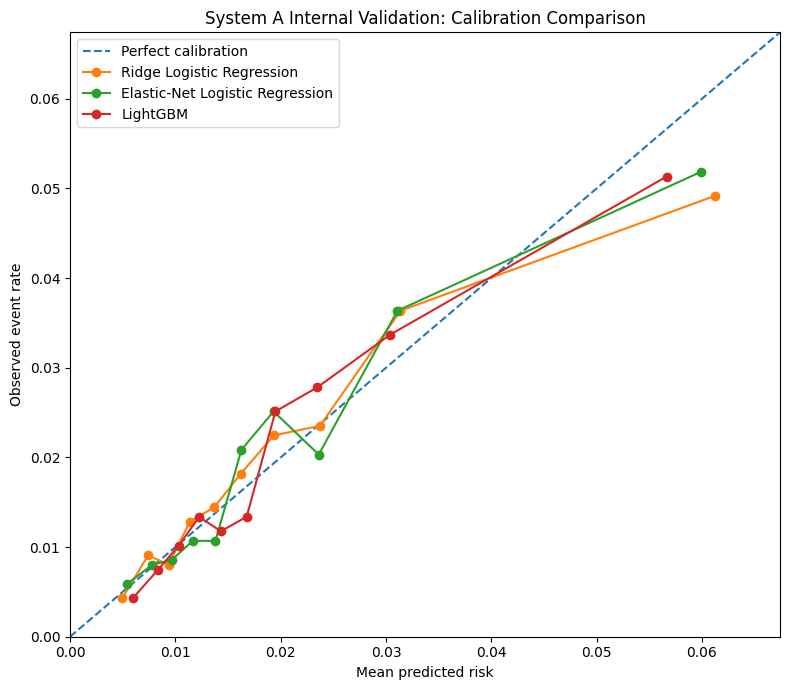

In [34]:
fig, ax = plt.subplots(
    figsize=(8, 7)
)

maximum_risk = max(
    combined_calibration_table[
        "mean_predicted_risk"
    ].max(),
    combined_calibration_table[
        "observed_event_rate"
    ].max(),
)

plot_limit = maximum_risk * 1.10

ax.plot(
    [0, plot_limit],
    [0, plot_limit],
    linestyle="--",
    label="Perfect calibration",
)

for model_name in model_oof_predictions:
    model_table = (
        combined_calibration_table.loc[
            combined_calibration_table[
                "model"
            ] == model_name
        ]
    )

    ax.plot(
        model_table[
            "mean_predicted_risk"
        ],
        model_table[
            "observed_event_rate"
        ],
        marker="o",
        label=model_name,
    )

ax.set_xlim(
    0,
    plot_limit,
)

ax.set_ylim(
    0,
    plot_limit,
)

ax.set_xlabel(
    "Mean predicted risk"
)

ax.set_ylabel(
    "Observed event rate"
)

ax.set_title(
    "System A Internal Validation: "
    "Calibration Comparison"
)

ax.legend()

plt.tight_layout()
plt.show()

## 10. Final Model Development on Full System A

Internal validation is now complete.

The nested cross-validation estimates above remain the reported
System A internal-validation performance.

For external validation, each specified model is now redeveloped
using the complete System A development cohort.

Hyperparameters are selected using 5-fold stratified cross-validation
within System A only, using the same frozen hyperparameter grids and
log loss criterion used during nested internal validation.

After hyperparameter selection, each model is refitted on all 18,699
System A patients.

No information from Health System B is used in model selection,
preprocessing, hyperparameter tuning, or fitting.

In [35]:
FINAL_TUNING_FOLDS = 5

final_tuning_cv = StratifiedKFold(
    n_splits=FINAL_TUNING_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

In [36]:
final_ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    scoring="neg_log_loss",
    cv=final_tuning_cv,
    refit=True,
    n_jobs=-1,
    return_train_score=False,
)

final_ridge_search.fit(
    X,
    y,
)

final_ridge_model = (
    final_ridge_search.best_estimator_
)

print(
    "Final Ridge parameters:"
)

print(
    final_ridge_search.best_params_
)

print(
    "Final Ridge CV log loss:"
)

print(
    -final_ridge_search.best_score_
)

Final Ridge parameters:
{'model__C': 0.03}
Final Ridge CV log loss:
0.09364056365474288


In [37]:
final_elastic_net_search = GridSearchCV(
    estimator=elastic_net_pipeline,
    param_grid=elastic_net_param_grid,
    scoring="neg_log_loss",
    cv=final_tuning_cv,
    refit=True,
    n_jobs=-1,
    return_train_score=False,
)

final_elastic_net_search.fit(
    X,
    y,
)

final_elastic_net_model = (
    final_elastic_net_search.best_estimator_
)

print(
    "Final Elastic-Net parameters:"
)

print(
    final_elastic_net_search.best_params_
)

print(
    "Final Elastic-Net CV log loss:"
)

print(
    -final_elastic_net_search.best_score_
)

Final Elastic-Net parameters:
{'model__C': 0.1, 'model__l1_ratio': 0.5}
Final Elastic-Net CV log loss:
0.09305146040342879


In [38]:
final_lightgbm_search = GridSearchCV(
    estimator=lightgbm_model,
    param_grid=lightgbm_param_grid,
    scoring="neg_log_loss",
    cv=final_tuning_cv,
    refit=True,
    n_jobs=-1,
    return_train_score=False,
)

final_lightgbm_search.fit(
    X,
    y,
)

final_lightgbm_model = (
    final_lightgbm_search.best_estimator_
)

print(
    "Final LightGBM parameters:"
)

print(
    final_lightgbm_search.best_params_
)

print(
    "Final LightGBM CV log loss:"
)

print(
    -final_lightgbm_search.best_score_
)

Final LightGBM parameters:
{'learning_rate': 0.03, 'min_child_samples': 100, 'n_estimators': 600, 'num_leaves': 2}
Final LightGBM CV log loss:
0.09252704758319727


In [39]:
final_model_specification = pd.DataFrame(
    [
        {
            "model":
                "Ridge Logistic Regression",
            "best_parameters":
                final_ridge_search.best_params_,
            "development_cv_log_loss":
                -final_ridge_search.best_score_,
        },
        {
            "model":
                "Elastic-Net Logistic Regression",
            "best_parameters":
                final_elastic_net_search.best_params_,
            "development_cv_log_loss":
                -final_elastic_net_search.best_score_,
        },
        {
            "model":
                "LightGBM",
            "best_parameters":
                final_lightgbm_search.best_params_,
            "development_cv_log_loss":
                -final_lightgbm_search.best_score_,
        },
    ]
)

final_model_specification

,model,best_parameters,development_cv_log_loss
0,Ridge Logistic Regression,{'model__C': 0.03},0.093641
1,Elastic-Net Logistic Regression,"{'model__C': 0.1, 'model__l1_ratio': 0.5}",0.093051
2,LightGBM,"{'learning_rate': 0.03, 'min_child_samples': 1...",0.092527


## 11. Freeze System A Models and Internal-Validation Artifacts

Internal validation and final model development are complete.

The three specified model classes are retained for external
validation regardless of their relative System A performance.

The following artifacts are frozen and saved:

- final models refitted on the complete System A cohort;
- patient-level out-of-fold predictions;
- frozen outer-fold assignments;
- internal-validation performance summaries;
- bootstrap confidence intervals;
- paired model comparisons;
- final hyperparameters;
- exact predictor ordering and feature roles.

These artifacts will be used without modification during external
validation in Health System B.

In [40]:
import json
import joblib


FROZEN_DIR = (
    ROOT
    / "results"
    / "frozen"
)

MODEL_DIR = (
    FROZEN_DIR
    / "models"
)

TABLE_DIR = (
    FROZEN_DIR
    / "tables"
)

PREDICTION_DIR = (
    FROZEN_DIR
    / "predictions"
)

METADATA_DIR = (
    FROZEN_DIR
    / "metadata"
)

for directory in [
    MODEL_DIR,
    TABLE_DIR,
    PREDICTION_DIR,
    METADATA_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

In [41]:
RIDGE_MODEL_PATH = (
    MODEL_DIR
    / "ridge_system_a.joblib"
)

ELASTIC_NET_MODEL_PATH = (
    MODEL_DIR
    / "elastic_net_system_a.joblib"
)

LIGHTGBM_MODEL_PATH = (
    MODEL_DIR
    / "lightgbm_system_a.joblib"
)

joblib.dump(
    final_ridge_model,
    RIDGE_MODEL_PATH,
)

joblib.dump(
    final_elastic_net_model,
    ELASTIC_NET_MODEL_PATH,
)

joblib.dump(
    final_lightgbm_model,
    LIGHTGBM_MODEL_PATH,
)

print(
    f"Saved Ridge model:\n"
    f"{RIDGE_MODEL_PATH.relative_to(ROOT)}"
)

print(
    f"\nSaved Elastic-Net model:\n"
    f"{ELASTIC_NET_MODEL_PATH.relative_to(ROOT)}"
)

print(
    f"\nSaved LightGBM model:\n"
    f"{LIGHTGBM_MODEL_PATH.relative_to(ROOT)}"
)

Saved Ridge model:
results/frozen/models/ridge_system_a.joblib

Saved Elastic-Net model:
results/frozen/models/elastic_net_system_a.joblib

Saved LightGBM model:
results/frozen/models/lightgbm_system_a.joblib


In [42]:
oof_predictions = pd.DataFrame(
    {
        "patient_id":
            system_a[ID_COLUMN].to_numpy(),

        "outcome":
            y.to_numpy(),

        "outer_fold":
            outer_fold,

        "ridge_probability":
            ridge_oof_probability,

        "elastic_net_probability":
            elastic_net_oof_probability,

        "lightgbm_probability":
            lightgbm_oof_probability,
    }
)

assert len(oof_predictions) == 18699

assert (
    oof_predictions[
        [
            "ridge_probability",
            "elastic_net_probability",
            "lightgbm_probability",
        ]
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

OOF_PREDICTION_PATH = (
    PREDICTION_DIR
    / "system_a_oof_predictions.csv"
)

oof_predictions.to_csv(
    OOF_PREDICTION_PATH,
    index=False,
)

oof_predictions.head()

,patient_id,outcome,outer_fold,ridge_probability,elastic_net_probability,lightgbm_probability
0,p000001,0,1,0.040656,0.052722,0.023123
1,p000002,0,4,0.009616,0.008048,0.008130
2,p000003,0,4,0.051949,0.045815,0.060311
3,p000004,0,3,0.004777,0.004986,0.003723
4,p000005,0,2,0.018025,0.014321,0.017156


In [43]:
internal_validation_summary.to_csv(
    TABLE_DIR
    / "internal_validation_summary.csv",
    index=False,
)

ridge_confidence_intervals.to_csv(
    TABLE_DIR
    / "ridge_confidence_intervals.csv",
    index=False,
)

elastic_net_confidence_intervals.to_csv(
    TABLE_DIR
    / "elastic_net_confidence_intervals.csv",
    index=False,
)

lightgbm_confidence_intervals.to_csv(
    TABLE_DIR
    / "lightgbm_confidence_intervals.csv",
    index=False,
)

ridge_vs_elastic_net.to_csv(
    TABLE_DIR
    / "ridge_vs_elastic_net.csv",
    index=False,
)

lightgbm_vs_linear_comparison.to_csv(
    TABLE_DIR
    / "lightgbm_vs_linear_comparison.csv",
    index=False,
)

combined_calibration_table.to_csv(
    TABLE_DIR
    / "system_a_calibration_deciles.csv",
    index=False,
)

print(
    "Saved frozen internal-validation tables."
)

Saved frozen internal-validation tables.


In [44]:
frozen_model_specification = {
    "study_design": {
        "landmark_hour": 6,
        "prediction_horizon_end_hour": 18,
        "development_system": "A",
        "external_validation_system": "B",
        "internal_validation_outer_folds": 5,
        "inner_tuning_folds": 3,
        "final_tuning_folds": 5,
        "tuning_metric": "neg_log_loss",
        "random_state": RANDOM_STATE,
    },

    "features": {
        "n_model_features":
            len(feature_columns),

        "feature_columns":
            feature_columns,

        "continuous_feature_columns":
            continuous_feature_columns,

        "binary_feature_columns":
            binary_feature_columns,
    },

    "models": {
        "ridge_logistic_regression": {
            "best_parameters":
                final_ridge_search.best_params_,

            "development_cv_log_loss":
                float(
                    -final_ridge_search.best_score_
                ),
        },

        "elastic_net_logistic_regression": {
            "best_parameters":
                final_elastic_net_search.best_params_,

            "development_cv_log_loss":
                float(
                    -final_elastic_net_search.best_score_
                ),
        },

        "lightgbm": {
            "best_parameters":
                final_lightgbm_search.best_params_,

            "development_cv_log_loss":
                float(
                    -final_lightgbm_search.best_score_
                ),
        },
    },
}

MODEL_SPECIFICATION_PATH = (
    METADATA_DIR
    / "system_a_model_specification.json"
)

with open(
    MODEL_SPECIFICATION_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        frozen_model_specification,
        file,
        indent=2,
    )

print(
    json.dumps(
        frozen_model_specification[
            "models"
        ],
        indent=2,
    )
)

{
  "ridge_logistic_regression": {
    "best_parameters": {
      "model__C": 0.03
    },
    "development_cv_log_loss": 0.09364056365474288
  },
  "elastic_net_logistic_regression": {
    "best_parameters": {
      "model__C": 0.1,
      "model__l1_ratio": 0.5
    },
    "development_cv_log_loss": 0.09305146040342879
  },
  "lightgbm": {
    "best_parameters": {
      "learning_rate": 0.03,
      "min_child_samples": 100,
      "n_estimators": 600,
      "num_leaves": 2
    },
    "development_cv_log_loss": 0.09252704758319727
  }
}


### Frozen Artifact Integrity Check

Saved model artifacts are reloaded and compared with their in-memory
counterparts before external validation.

Prediction equivalence is verified on a fixed subset of System A
patients to confirm successful serialization.

The existence of the frozen prediction and metadata artifacts is also
verified.

In [45]:
reloaded_ridge_model = joblib.load(
    RIDGE_MODEL_PATH
)

reloaded_elastic_net_model = joblib.load(
    ELASTIC_NET_MODEL_PATH
)

reloaded_lightgbm_model = joblib.load(
    LIGHTGBM_MODEL_PATH
)


integrity_X = X.iloc[
    :250
].copy()


np.testing.assert_allclose(
    reloaded_ridge_model.predict_proba(
        integrity_X
    )[:, 1],
    final_ridge_model.predict_proba(
        integrity_X
    )[:, 1],
    rtol=1e-12,
    atol=1e-12,
)

np.testing.assert_allclose(
    reloaded_elastic_net_model.predict_proba(
        integrity_X
    )[:, 1],
    final_elastic_net_model.predict_proba(
        integrity_X
    )[:, 1],
    rtol=1e-12,
    atol=1e-12,
)

np.testing.assert_allclose(
    reloaded_lightgbm_model.predict_proba(
        integrity_X
    )[:, 1],
    final_lightgbm_model.predict_proba(
        integrity_X
    )[:, 1],
    rtol=1e-12,
    atol=1e-12,
)


for artifact_path in [
    RIDGE_MODEL_PATH,
    ELASTIC_NET_MODEL_PATH,
    LIGHTGBM_MODEL_PATH,
    OOF_PREDICTION_PATH,
    MODEL_SPECIFICATION_PATH,
]:
    assert artifact_path.exists()

    assert (
        artifact_path.stat().st_size
        > 0
    )


assert len(oof_predictions) == 18699

assert (
    oof_predictions["patient_id"]
    .duplicated()
    .sum()
    == 0
)

assert int(
    oof_predictions["outcome"].sum()
) == 371

assert set(
    oof_predictions["outer_fold"]
    .unique()
) == {1, 2, 3, 4, 5}


print(
    "Frozen artifact integrity check passed."
)

Frozen artifact integrity check passed.


## 12. Final Status

**System A model development is frozen.**

Three specified model classes have completed nested internal
validation and final redevelopment on the full System A cohort:

- Ridge logistic regression;
- Elastic-Net logistic regression;
- LightGBM.

All internal-validation performance estimates were obtained from
out-of-fold predictions.

Final models were fitted only after internal validation was complete and
are reserved for external evaluation.

The serialized frozen models and associated validation artifacts have
passed integrity checks.

No Health System B data have been examined, summarized, used for
preprocessing, or used for model selection.

The next stage is locked external validation of the frozen System A
pipelines in Health System B.